# Stabilizers and quantum LDPC codes

Classical LDPC codes are just codes that admit a sparse parity check matrix.

I say "admit" because a code can have many equivalent parity check matrices.

In the stabilzer language (the stabilizer formalism) this would mean that there is a representation in which, each stabilizer acts non trivially on a small set of physical qubits (we say the stabilizer has low weight), and each qubit is acted on by a small number of stabilizers.

The usual entry point (to all quantum ECC these days) is the surface code which I'll describe for 13 qubits, in a way that matches [The ZX calculus is a language for surface code lattice surgery](https://quantum-journal.org/wp-content/uploads/2020/06/q-2020-01-09-218.pdf) and the following picture taken from it:

![Surface code example](./figures/surfaceCodeExample.png)

Start with an array of qubits as follows:

q0 --- q1 --- q2

    |       |

    q3 --- q4

    |       |

q5 --- q6 --- q7

    |       |

    q8 --- q9

    |       |

q10--- q11 ---q12

Then add stabilizer generators (relations between qubits) as follows:



Z0Z3Z5 = ZIIZIZIIIIIII = [0,3,5]

What really matters is really just the indices which are not trivial.

So for example Z2Z4Z7 can be represented as:

(2,4,7)

Or more explicitly:

(2,4,7) = np.where([0,0,1,0,1,0,0,1,0,0,0,0,0])

Z1Z4Z6Z3 = [1,4,6,3]

Z2Z4Z7 = [2,4,7]

Z5Z8Z10 = [5,8,10]

Z6Z8Z9Z11 = [6,8,9,11]

Z7Z9Z12 = [7,9,12]

Similarly we define:
X

And for now we define 
$$S = \{Z1Z4Z6Z3, Z2Z4Z7, Z5Z8Z10, Z6Z8Z9Z11, Z7Z9Z12, Z2Z4Z7\}$$

$$\langle S \rangle = \{ s_0 \cdot s_1 ,... \cdot s_{n-1} : \text{n is an integer}, s_i \in S\}$$

Meaning $\langle S \rangle$ is the subgroup of $P^n$ generated by the elements of $S$.


In [7]:
import numpy as np
from qecc.funWithMatrices import binaryGaussianEliminationOnRows
stabilizers = []
zList = []

Z0Z3Z5 = [0,3,5]
zList.append(Z0Z3Z5)
Z1Z4Z6Z3 = [1,4,6,3]
zList.append(Z1Z4Z6Z3)
Z2Z4Z7 = [2,4,7]
zList.append(Z2Z4Z7)
Z5Z8Z10 = [5,8,10]
zList.append(Z5Z8Z10)
Z6Z8Z9Z11 = [6,8,9,11]
zList.append(Z6Z8Z9Z11)
Z7Z9Z12 = [7,9,12]
zList.append(Z7Z9Z12)

for z in zList:
    tmp = np.zeros(13, dtype = int)
    tmp[z]  = 1
    stabilizers.append(tmp)

stabilizerMatrix = np.array(stabilizers)
print(stabilizerMatrix)

wan = np.ones(13, dtype = int)

temp = np.vstack((wan, stabilizerMatrix))
a,b,c = binaryGaussianEliminationOnRows(temp)
print(a)
print(np.where(a[0] == 1))

[[1 0 0 1 0 1 0 0 0 0 0 0 0]
 [0 1 0 1 1 0 1 0 0 0 0 0 0]
 [0 0 1 0 1 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 1 0 1 0 0]
 [0 0 0 0 0 0 1 0 1 1 0 1 0]
 [0 0 0 0 0 0 0 1 0 1 0 0 1]]
[[1 0 0 0 1 1 0 0 1 1 1 1 1]
 [0 1 0 0 0 0 1 0 1 1 1 1 1]
 [0 0 1 0 1 0 0 1 0 0 0 0 0]
 [0 0 0 1 1 0 0 0 1 1 1 1 1]
 [0 0 0 0 0 1 0 0 1 0 1 0 0]
 [0 0 0 0 0 0 1 0 1 1 0 1 0]
 [0 0 0 0 0 0 0 1 0 1 0 0 1]]
(array([ 0,  4,  5,  8,  9, 10, 11, 12]),)


So we are using the isomorphism from Paulis to dual binary representation, where multiplication of Paulis translates to addidtion modulo 2.

To check whether a Pauli operator that has only $I$ and $Z$ entries is in $\langle S \rangle$, we can check whether it is in the row span of the matrix, which rows are the binary representations of the stabilizers !

The next thing we would like to check, is that applying Z1Z2Z3 is equivalent to Z6Z7ZZ8.

What is applying Z to all qubits equivalent to:

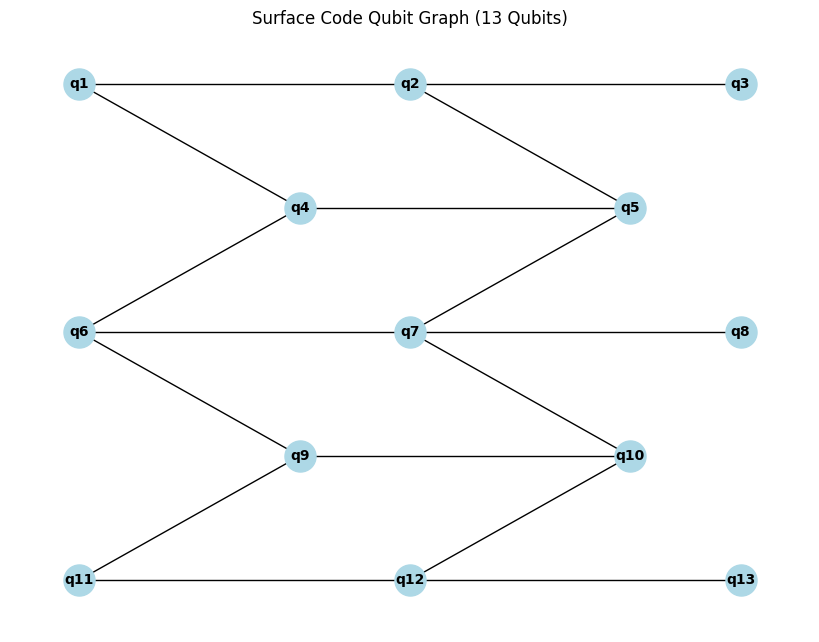

In [1]:
import networkx as nx


import matplotlib.pyplot as plt

# Define qubit positions based on the description
positions = {
    'q11': (0, 0), 'q12': (3, 0), 'q13': (6, 0),
    'q9': (2, 1), 'q10': (5, 1),
    'q6': (0, 2), 'q7': (3, 2), 'q8': (6, 2),
    'q4': (2, 3), 'q5': (5, 3),
    'q1': (0, 4), 'q2': (3, 4), 'q3': (6, 4)
}

# Define edges based on the --- and | connections
edges = [
    ('q1', 'q2'), ('q2', 'q3'), ('q4', 'q5'), ('q6', 'q7'), ('q7', 'q8'), ('q9', 'q10'), ('q11', 'q12'), ('q12', 'q13'),
    ('q1', 'q4'), ('q2', 'q5'), ('q4', 'q6'), ('q5', 'q7'), ('q6', 'q9'), ('q7', 'q10'), ('q9', 'q11'), ('q10', 'q12')
]

# Create the graph
G = nx.Graph()
G.add_nodes_from(positions.keys())
G.add_edges_from(edges)

# Draw the graph
plt.figure(figsize=(8, 6))
nx.draw(G, pos=positions, with_labels=True, node_color='lightblue', node_size=500, font_size=10, font_weight='bold')
plt.title('Surface Code Qubit Graph (13 Qubits)')
plt.axis('off')
plt.show()

We have the following explanation extracted from [High-threshold and low-overhead fault-tolerant quantum memory](https://arxiv.org/pdf/2308.07915):

![image.png](./figures/bbCodeConstruction.png)

In [ ]:


import numpy as np
from qecc.polynomialCodes import generateBicycleCode
from qecc.funWithMatrices import binaryGaussianEliminationOnRows


aX = [3]
aY = [1,2]
bX = [1,2]
bY = [3]

Hx, Hz = generateBicycleCode(6,6,aX,aY,bX,bY)
for i in range(Hx.shape[0]):
    for j in range(Hx.shape[1]):
        print(Hx[i][j], end=' ')
    print()
_,_,r = binaryGaussianEliminationOnRows(Hz)
print(r)




We have the following parameters provided by [High-threshold and low-overhead fault-tolerant quantum memory](https://arxiv.org/pdf/2308.07915):
![image.png](./figures/bbCodeParameters.png)

[Batched high-rate logical operations for quantum LDPC codes](https://arxiv.org/abs/2510.06159)
[Quantum fault tolerance in small experiments](https://arxiv.org/abs/1610.03507)
[]()
